In [1]:
import os
import sys

sys.path.append(os.path.join(os.path.dirname(__vsc_ipynb_file__), ".."))

import numpy as np
import numba
import matplotlib.pyplot as plt

from params import RestrepoParams
from cpu import *
from utils import time_renormalisation, Iup, Ileak, _rho, _Mhat, luminal_buffer
from sde import mean_reverting_gbm, levy_ou_process

In [2]:
params = RestrepoParams()

In [460]:
#nb_cru = RestrepoCPU(params=RestrepoParams(Ku=1.4e-4))
nb_cru = RestrepoCPU(params=RestrepoParams())
nb_cru.forward(1e-3, 5_000_000, clamp=False)

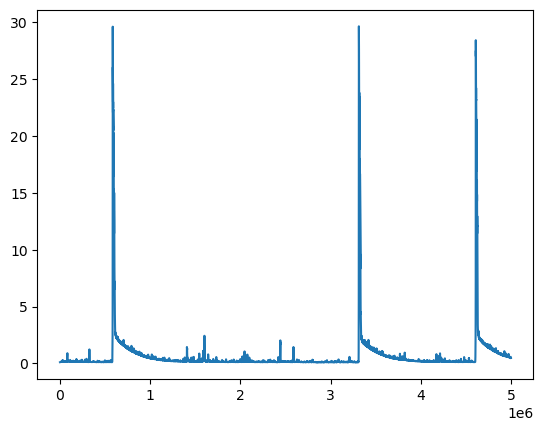

In [461]:
plt.plot(nb_cru.cs)
plt.show()

In [512]:
def quintic_coeff(R1, cjsr, cs):
    return (5.93e-8 * R1 + 1.61e-7) / (cjsr - cs)**2

def quartic_coeff(R1, cjsr, cs):
    return (2.29e-5 * R1 * cjsr - 2.23e-5 * R1 * cs + 6.25e-5*cjsr -6.30e-5*cs) / (cjsr - cs)**2

def cubic_coeff(R1, cjsr, cs):
    return (-4.60e-5 * R1 * cjsr**2 + 4.62e-5 * R1 * cjsr*cs - 7.54e-5*cjsr**2 
            +2.60e-5*cjsr*cs + 5e-5*cs**2 - 2.567e-3) / (cjsr - cs)**2

def quadratic_coeff(R1, cjsr, cs):
    return (2.3e-5 * R1 * cjsr**3 - 2.31e-5 * R1 * cjsr**2*cs + 1.28e-5*cjsr**3 
            +3.70e-5*cjsr**2*cs - 5e-5*cjsr*cs**2 + 1.005*cjsr - 0.9974) / (cjsr - cs)**2

def linear_coeff(cjsr, cs):
    return (-1.0026*cjsr**2 + cs**2 - 0.5134*cjsr*cs) / (cjsr-cs)**2

def const_coeff(cjsr, cs):
    return (cjsr*cs*(1.0026*cjsr-cs)) / (cjsr-cs)**2

def poly(cp, cjsr, cs, R1, degree=5):
    a = quintic_coeff(R1, cjsr, cs)
    b = quartic_coeff(R1, cjsr, cs)
    c = cubic_coeff(R1, cjsr, cs)
    d = quadratic_coeff(R1, cjsr, cs)
    e = linear_coeff(cjsr, cs)
    f = const_coeff(cjsr, cs)
    if degree == 5:
        return a*cp**5 + b* cp**4 + c*cp**3 + d*cp**2 + e*cp + f
    elif degree == 4:
        return b* cp**4 + c*cp**3 + d*cp**2 + e*cp + f
    elif degree == 3:
        return c*cp**3 + d*cp**2 + e*cp + f
    elif degree == 2:
        return d*cp**2 + e*cp + f
    elif degree == 1:
        return e*cp + f
    elif degree == -3:
        # cant be bothered adding another option to do this
        return 0.9*c*cp**3 + d*cp**2 + e*cp + f



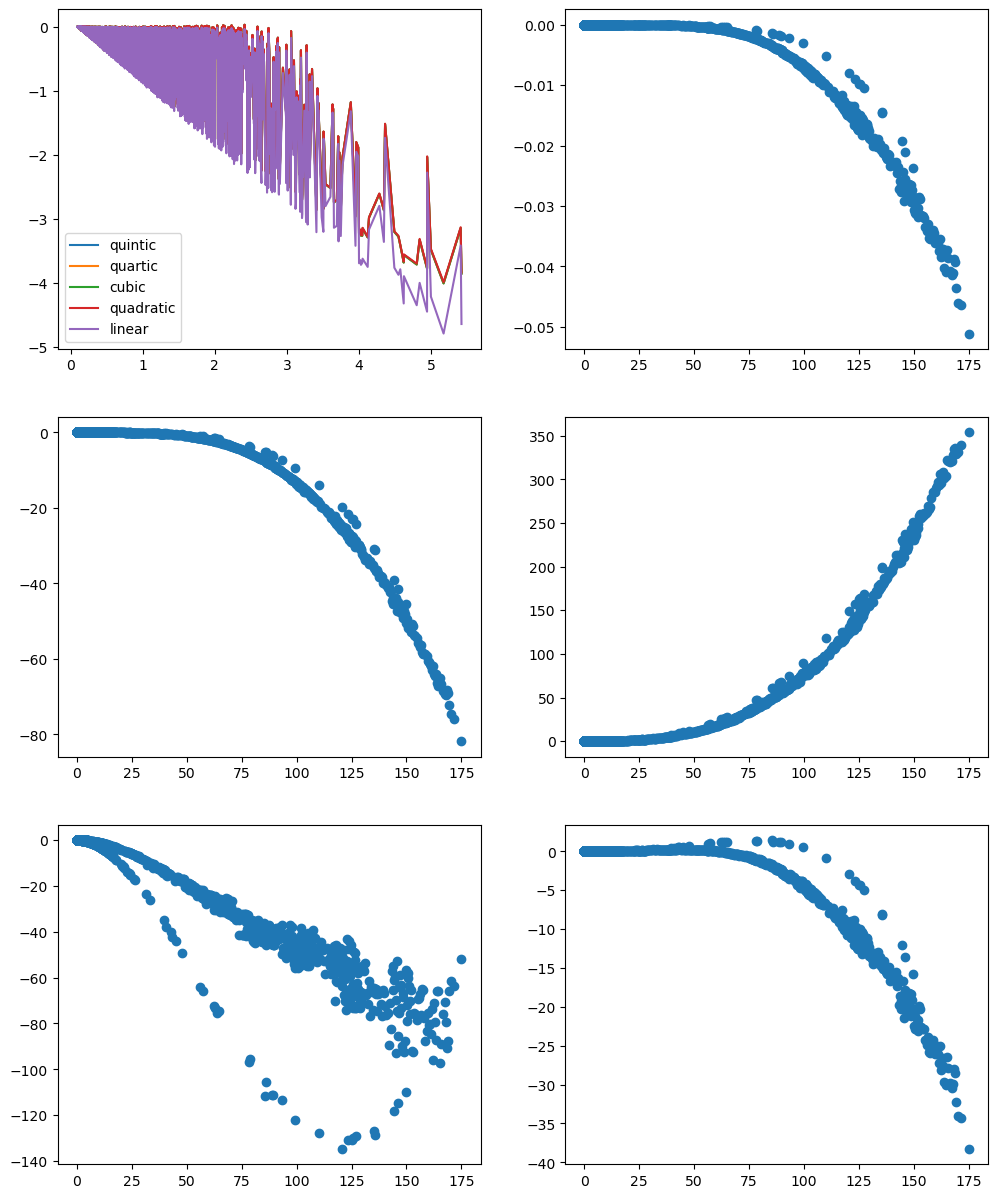

In [533]:
fig, ax = plt.subplots(3,2, figsize=(12,15))

idx = np.argsort(nb_cru.cp[::1000])
ax[0,0].plot(nb_cru.cp[::1000][idx[:-100]], poly(nb_cru.cp[::1000], nb_cru.cjsr[::1000], nb_cru.cs[::1000], nb_cru.RyR[::1000, 0], degree=5)[idx[:-100]], label="quintic")
ax[0,0].plot(nb_cru.cp[::1000][idx[:-100]], poly(nb_cru.cp[::1000], nb_cru.cjsr[::1000], nb_cru.cs[::1000], nb_cru.RyR[::1000, 0], degree=4)[idx[:-100]], label="quartic")
ax[0,0].plot(nb_cru.cp[::1000][idx[:-100]], poly(nb_cru.cp[::1000], nb_cru.cjsr[::1000], nb_cru.cs[::1000], nb_cru.RyR[::1000, 0], degree=3)[idx[:-100]], label="cubic")
ax[0,0].plot(nb_cru.cp[::1000][idx[:-100]], poly(nb_cru.cp[::1000], nb_cru.cjsr[::1000], nb_cru.cs[::1000], nb_cru.RyR[::1000, 0], degree=2)[idx[:-100]], label="quadratic")
ax[0,0].plot(nb_cru.cp[::1000][idx[:-100]], poly(nb_cru.cp[::1000], nb_cru.cjsr[::1000], nb_cru.cs[::1000], nb_cru.RyR[::1000, 0], degree=1)[idx[:-100]], label="linear")
ax[0,0].legend()

#cps = np.linspace(0,200,num=1000)
idx = np.argsort(nb_cru.cp)
p5 = poly(nb_cru.cp, nb_cru.cjsr, nb_cru.cs, nb_cru.RyR[:, 0], degree=5)[idx]
p4 = poly(nb_cru.cp, nb_cru.cjsr, nb_cru.cs, nb_cru.RyR[:, 0], degree=4)[idx]
p3 = poly(nb_cru.cp, nb_cru.cjsr, nb_cru.cs, nb_cru.RyR[:, 0], degree=3)[idx]
p2 = poly(nb_cru.cp, nb_cru.cjsr, nb_cru.cs, nb_cru.RyR[:, 0], degree=2)[idx]
p1 = poly(nb_cru.cp, nb_cru.cjsr, nb_cru.cs, nb_cru.RyR[:, 0], degree=1)[idx]
p3_mod = poly(nb_cru.cp, nb_cru.cjsr, nb_cru.cs, nb_cru.RyR[:, 0], degree=-3)[idx]
ax[0,1].scatter(nb_cru.cp[idx][::100], p4[::100] - p5[::100])
ax[1,0].scatter(nb_cru.cp[idx][::100], p3[::100] - p5[::100])
ax[1,1].scatter(nb_cru.cp[idx][::100], p2[::100] - p5[::100])
ax[2,0].scatter(nb_cru.cp[idx][::100], p1[::100] - p5[::100])
ax[2,1].scatter(nb_cru.cp[idx][::100], p3_mod[::100] - p5[::100])

plt.show()

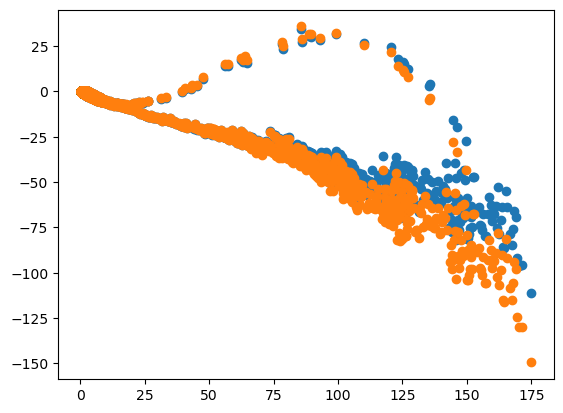

In [537]:
plt.scatter(nb_cru.cp[idx][::100], p5[::100])
plt.scatter(nb_cru.cp[idx][::100], p3_mod[::100])
plt.show()

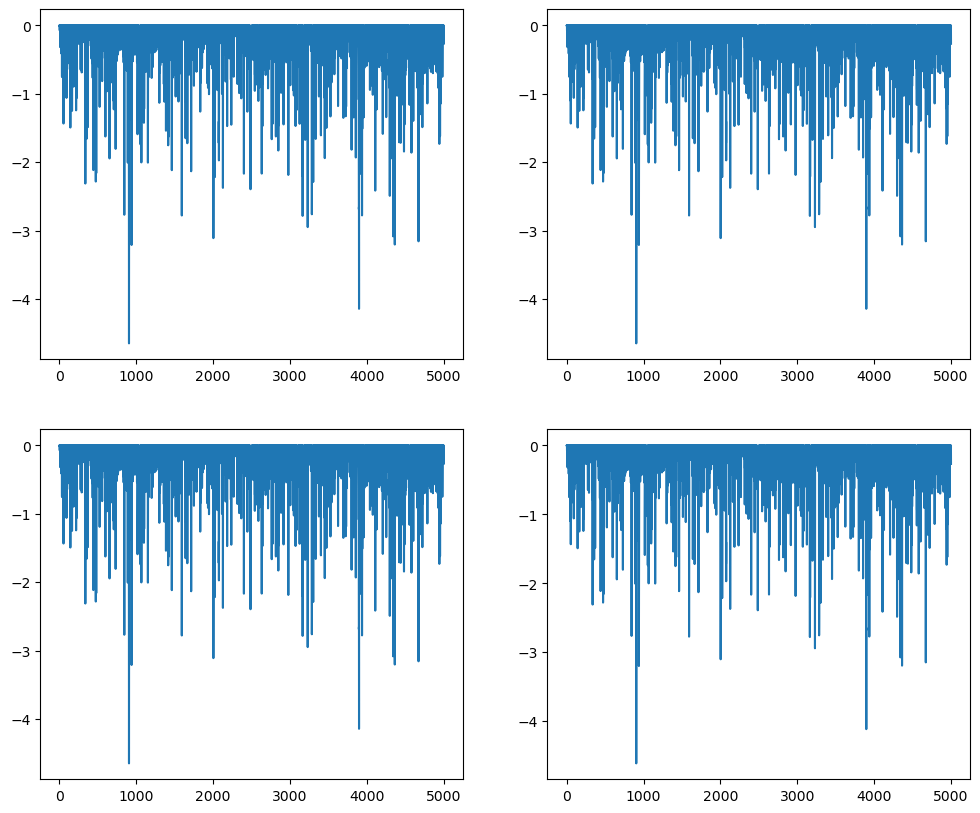

In [356]:
fig, ax = plt.subplots(2,2, figsize=(12,10))
ax[0,0].plot(nb_cru.t[::1000], poly(nb_cru.cp[::1000], nb_cru.cjsr[::1000], nb_cru.cs[::1000], nb_cru.RyR[::1000, 0], degree=5))
ax[0,1].plot(nb_cru.t[::1000], poly(nb_cru.cp[::1000], nb_cru.cjsr[::1000], nb_cru.cs[::1000], nb_cru.RyR[::1000, 0], degree=4))
ax[1,0].plot(nb_cru.t[::1000], poly(nb_cru.cp[::1000], nb_cru.cjsr[::1000], nb_cru.cs[::1000], nb_cru.RyR[::1000, 0], degree=3))
ax[1,1].plot(nb_cru.t[::1000], poly(nb_cru.cp[::1000], nb_cru.cjsr[::1000], nb_cru.cs[::1000], nb_cru.RyR[::1000, 0], degree=2))
plt.show()

In [308]:
0.010752 + 1 / 840

0.01194247619047619

In [48]:
def kolmogorov(RyR, cs, cjsr, params):
    Po = RyR[1] + RyR[2]
    R4 = 1 - RyR.sum()
    kr = params.tau_ps * params.Jmax / params.vp
    cp = (cs + kr * Po * cjsr) / (1 + kr * Po)
    Mhat = _Mhat(_rho(cjsr, params), params.BCSQN)

    out = np.zeros(3)
    out[0] = RyR[1] / params.tau_c + R4 / params.tau_u - (params.Ku * cp**2 + Mhat / params.tau_b) * RyR[0]
    out[1] = params.Ku * cp**2 * RyR[0] + params.Ku / (params.Kb * params.tau_u) * RyR[2] - (1 / params.tau_c + Mhat / params.tau_b) * RyR[1]
    out[2] = (Mhat / params.tau_b) * RyR[1] + params.Kb * cp**2 * R4 - (1 / params.tau_c + params.Ku / (params.Kb * params.tau_u)) * RyR[2]
    return out

def sigma1(R1, R2, R3, cs, cjsr, params):
    Mhat = _Mhat(_rho(cjsr, params), params.BCSQN)
    kr = params.tau_ps * params.Jmax / params.vp
    cp = (cs + kr * (R2 + R3) * cjsr) / (1 + kr * (R2 + R3))

    k21 = 1 / params.tau_c
    k12 = params.Ku * cp**2

    k41 = 1 / params.tau_u
    k14 = Mhat / params.tau_b

    return np.sqrt(k21 * R2 + k12 * R1 + k41 * R1 + k14 * (1 - R1 - R2 - R3))

def sigma2(R1, R2, R3, cs, cjsr, params):
    Mhat = _Mhat(_rho(cjsr, params), params.BCSQN)
    kr = params.tau_ps * params.Jmax / params.vp
    cp = (cs + kr * (R2 + R3) * cjsr) / (1 + kr * (R2 + R3))

    k21 = 1 / params.tau_c
    k12 = params.Ku * cp**2

    k23 = Mhat / params.tau_b
    k32 = params.Ku / (params.Kb * params.tau_u)

    return np.sqrt(k21 * R2 + k12 * R1 + k23 * R2 + k32 * R3)

def sigma3(R1, R2, R3, cs, cjsr, params):
    Mhat = _Mhat(_rho(cjsr, params), params.BCSQN)
    kr = params.tau_ps * params.Jmax / params.vp
    cp = (cs + kr * (R2 + R3) * cjsr) / (1 + kr * (R2 + R3))
    
    k23 = Mhat / params.tau_b
    k32 = params.Ku / (params.Kb * params.tau_u)

    k34 = 1 / params.tau_c
    k43 = params.Kb * cp**2

    return np.sqrt(k34 * R3 + k43 * (1 - R1 - R2 - R3) + k23 * R2 + k32 * R3)

def sigmaPo(R1, R2, R3, cs, cjsr, params):
    kr = params.tau_ps * params.Jmax / params.vp
    cp = (cs + kr * (R2 + R3) * cjsr) / (1 + kr * (R2 + R3))
    
    k21 = 1 / params.tau_c
    k12 = params.Ku * cp**2

    k34 = 1 / params.tau_c
    k43 = params.Kb * cp**2

    return np.sqrt(k34 * R3 + k43 * (1 - R1 - R2 - R3) + k12 * R1 + k21 * R1)

def sigma1_Po(R1, Po, cs, cjsr, params):
    Mhat = _Mhat(_rho(cjsr, params), params.BCSQN)
    k23 = Mhat / params.tau_b
    k32 = params.Ku / (params.Kb * params.tau_u)
    
    R2 = Po * k32 / (k32 + k23)
    R3 = Po  - R2
    return sigma1(R1, R2, R3, cs, cjsr, params)

def sigmaPo_Po(R1, Po, cs, cjsr, params):
    Mhat = _Mhat(_rho(cjsr, params), params.BCSQN)
    k23 = Mhat / params.tau_b
    k32 = params.Ku / (params.Kb * params.tau_u)
    
    R2 = Po * k32 / (k32 + k23)
    R3 = Po  - R2
    return sigmaPo(R1, R2, R3, cs, cjsr, params)

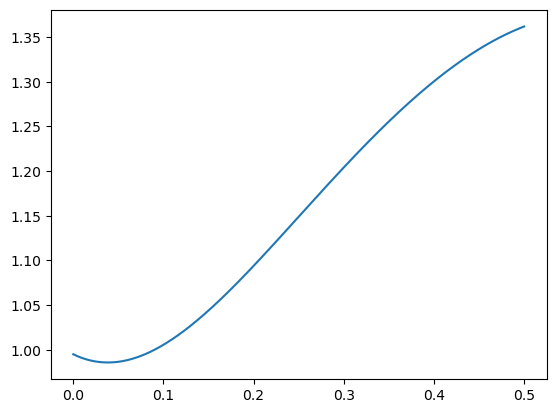

In [50]:
Pos = np.linspace(0, 0.5, num=1000)
plt.plot(Pos, sigmaPo_Po(0.99 - Pos, Pos, 0.1, 750.0, params))
plt.show()

In [20]:
def Po_coeffs(cs, cjsr, params):
    Mhat = _Mhat(_rho(cjsr, params), params.BCSQN)
    beta = params.Ku + (params.Kb * Mhat * params.tau_u) / params.tau_b
    gamma = 1.0 / (1.0 + Mhat * params.tau_u / params.tau_b)
    kr = params.tau_ps * params.Jmax / params.vp
    
    a = (kr**2) * (1 + beta*gamma*cjsr**2)
    b = kr * (2 - beta*gamma*cjsr*(kr*cjsr-2*cs))
    c = 1 - beta*gamma*cs*(2*kr*cjsr - cs)
    d = -beta*gamma*(cs**2)
    return a, b, c, d

def Po_poly(x, cs, cjsr, params):
    a, b, c, d = Po_coeffs(cs, cjsr, params)
    return x**3 + (b/a) * x**2 + (c/a) * x + (d/a)

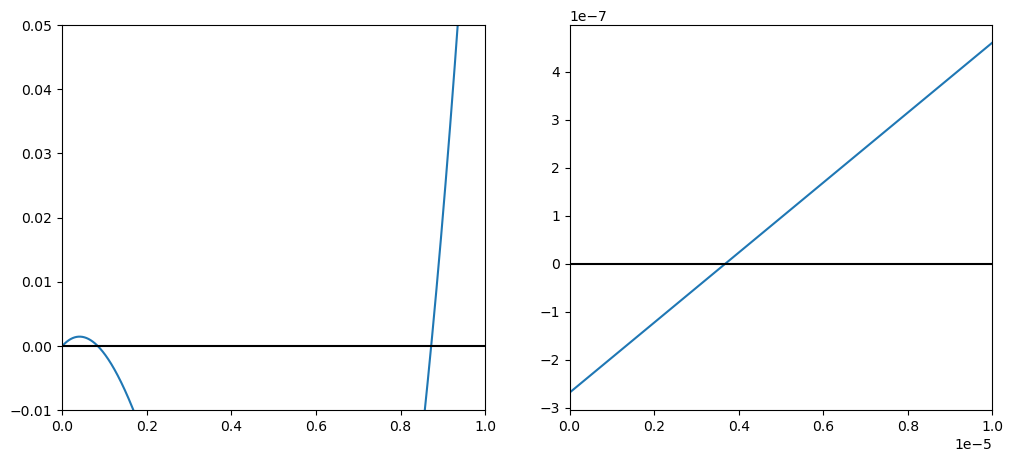

In [21]:
x = np.linspace(0,1, num=10000)
x_ = np.linspace(0, 1e-5, num=1000)
fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].plot(x, Po_poly(x, 0.1, 750.0, params))
ax[0].axhline(y=0, color='k')
ax[0].set_ylim(-0.01, 0.05)
ax[0].set_xlim(0, 1)

ax[1].plot(x_, Po_poly(x_, 0.1, 750.0, params))
ax[1].axhline(y=0, color='k')
ax[1].set_xlim(0, 1e-5)
plt.show()

In [22]:
def bisection(left, right, num, cs, cjsr, params, P_left=None, P_right=None):
    assert isinstance(num, int) and num >= 0
    if P_left is None:
        P_left = Po_poly(left, cs, cjsr, params)
    if P_right is None:
        P_right = Po_poly(right, cs, cjsr, params)

    assert np.sign(P_left) * np.sign(P_right) == -1

    if num == 0:
        x = (left + right) / 2
        return (left + right) / 2, Po_poly(x, cs, cjsr, params)
    else:
        x = (left + right) / 2
        val = Po_poly(x, cs, cjsr, params)
        if np.sign(val) * np.sign(P_left) == -1:
            return bisection(left, x, num-1, cs, cjsr, params, P_left=P_left, P_right=val)
        elif np.sign(val) * np.sign(P_right) == -1:
            return bisection(x, right, num-1, cs, cjsr, params, P_left=val, P_right=P_right)
        else:
            return x, val

def find_critical_point(cs, cjsr, params):
    a, b, c, d = Po_coeffs(cs, cjsr, params)

    Delta = 4*(b**2 - 3*a*c)
    if Delta < 0:
        return None, None
    
    r1 = (-2*b - np.sqrt(Delta)) / (6*a)
    r2 = (-2*b + np.sqrt(Delta)) / (6*a)

    if 6*a*r1 + 2*b > 0:
        return r1, r1**3 + (b/a) * r1**2 + (c/a) * r1 + d
    else:
        return r2, r2**3 + (b/a) * r2**2 + (c/a) * r2 + d

def solve_roots(cs, cjsr, params, num_bisection_iter=50):
    a, b, c, d = Po_coeffs(cs, cjsr, params)
    # Guess a value for the first root by using linearisation at zero
    upper = -d / c
    while True:
        if Po_poly(upper, cs, cjsr, params) < 0:
            upper *= 2
        else:
            break

    r1, Pr1 = bisection(0.0, upper, num_bisection_iter, cs, cjsr, params)

    crit, Pcrit = find_critical_point(cs, cjsr, params)
    if crit is None or Pcrit > 0:
        # No additional roots
        r2 = None
        Pr2 = None
        r3 = None
        Pr3 = None
    elif Pcrit == 0:
        # Repeated root
        r2 = crit
        Pr2 = Pcrit
        r3 = None
        Pr3 = None
    else:
        # root < critical point
        r2, Pr2 = bisection(upper, crit, num_bisection_iter, cs, cjsr, params)
        # root > critical point
        r3, Pr3 = bisection(crit, 1.0, num_bisection_iter, cs, cjsr, params)
    
    return {"root 1": (r1, Pr1), "root 2": (r2, Pr2), "root 3": (r3, Pr3)}

def Jacobian(Po, cs, cjsr, params):
    kr = params.tau_ps * params.Jmax / params.vp
    Mhat = _Mhat(_rho(cjsr, params), params.BCSQN)
    gamma = 1.0 / (1.0 + Mhat * params.tau_u / params.tau_b)
    
    cp = (cs + kr * Po * cjsr) / (1 + kr * Po)
    R1 = gamma * (1 - Po)
    R2 = params.Ku * params.tau_c * gamma * (1 - Po) * cp**2
    R3 = (params.Kb * Mhat * params.tau_c * params.tau_u / params.tau_b) * gamma * (1 - Po) * cp**2

    dcp_dR = kr * (cjsr - cs) / (1 + kr*Po)**2

    J = np.zeros((3,3))
    # (R1, R1)
    J[0,0] = -(params.Ku * cp**2 + Mhat/params.tau_b + 1/params.tau_u)
    # (R1, R2)
    J[0,1] = (1 / params.tau_c) - (1 / params.tau_u + 2*params.Ku*dcp_dR*cp*R1)
    # (R1, R3)
    J[0,2] = -(1 / params.tau_u + 2*params.Ku*dcp_dR*cp*R1)
    
    # (R2, R1)
    J[1,0] = params.Ku * cp**2
    # (R2, R2)
    J[1,1] = -(1 / params.tau_c + Mhat/params.tau_b) + 2*params.Ku*dcp_dR*cp*R1
    # (R2, R3)
    J[1,2] = params.Ku/(params.Kb*params.tau_b) + 2*params.Ku*dcp_dR*cp*R1
    
    # (R3, R1)
    J[2,0] = -params.Kb * cp**2
    # (R3, R2)
    J[2,1] = Mhat / params.tau_b +  2*params.Kb*dcp_dR*cp*(1-(R1+R2+R3)) - params.Kb*cp**2
    # (R3, R3)
    J[2,2] = 2*params.Kb*dcp_dR*cp*(1-(R1+R2+R3)) - (params.Kb*cp**2 + 1 / params.tau_c + params.Ku/(params.Kb*params.tau_u))
    return J

In [23]:
roots = solve_roots(0.1, 750.0, params)

In [24]:
roots

{'root 1': (3.6821779725201572e-06, -1.0587911840678754e-22),
 'root 2': (0.0835853256256106, 2.4009148889923143e-18),
 'root 3': (0.8725339028377297, 5.003000102957525e-18)}

In [25]:
np.linalg.eigvals(Jacobian(roots['root 1'][0], 0.1, 750.0, params))

array([-0.00843375, -1.07042941, -0.97673254])

In [26]:
def ccdf(arr: npt.NDArray):
    ps = np.arange(1, len(arr)+1) / len(arr)
    vals = np.sort(arr)[::-1]
    return ps, vals

In [20]:
nb_cru.reset_initial_conditions()
nb_cru.forward(1e-3, 20_000_000, clamp=False)

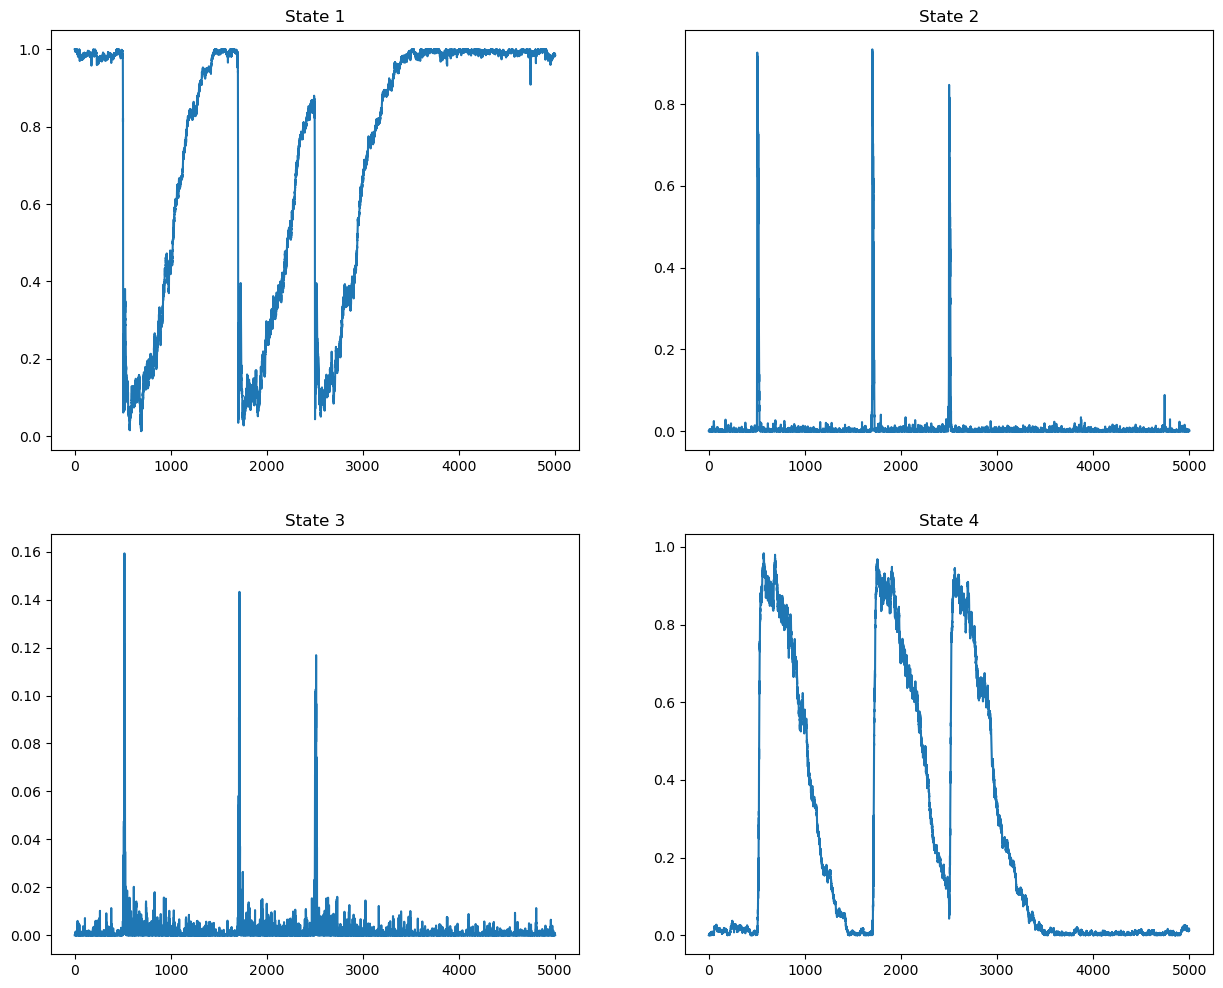

In [190]:
fig, ax = plt.subplots(2,2, figsize=(15,12))
ax[0,0].plot(nb_cru.t[::100], nb_cru.RyR[::100, 0])
ax[0,0].set_title("State 1")
ax[0,1].plot(nb_cru.t[::100], nb_cru.RyR[::100, 1])
ax[0,1].set_title("State 2")
ax[1,0].plot(nb_cru.t[::100], nb_cru.RyR[::100, 2])
ax[1,0].set_title("State 3")
ax[1,1].plot(nb_cru.t[::100], nb_cru.RyR[::100, 3])
ax[1,1].set_title("State 4")
plt.show()

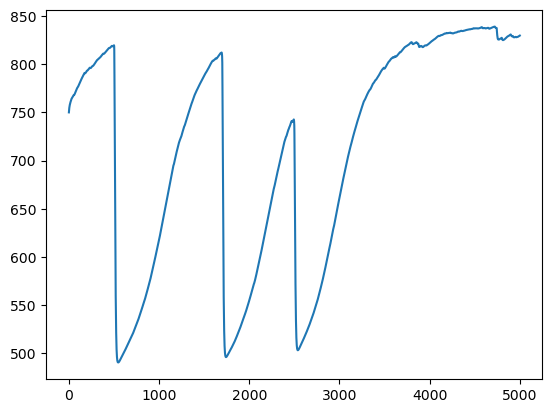

In [191]:
plt.plot(nb_cru.t[::100], nb_cru.cnsr[::100])
plt.show()

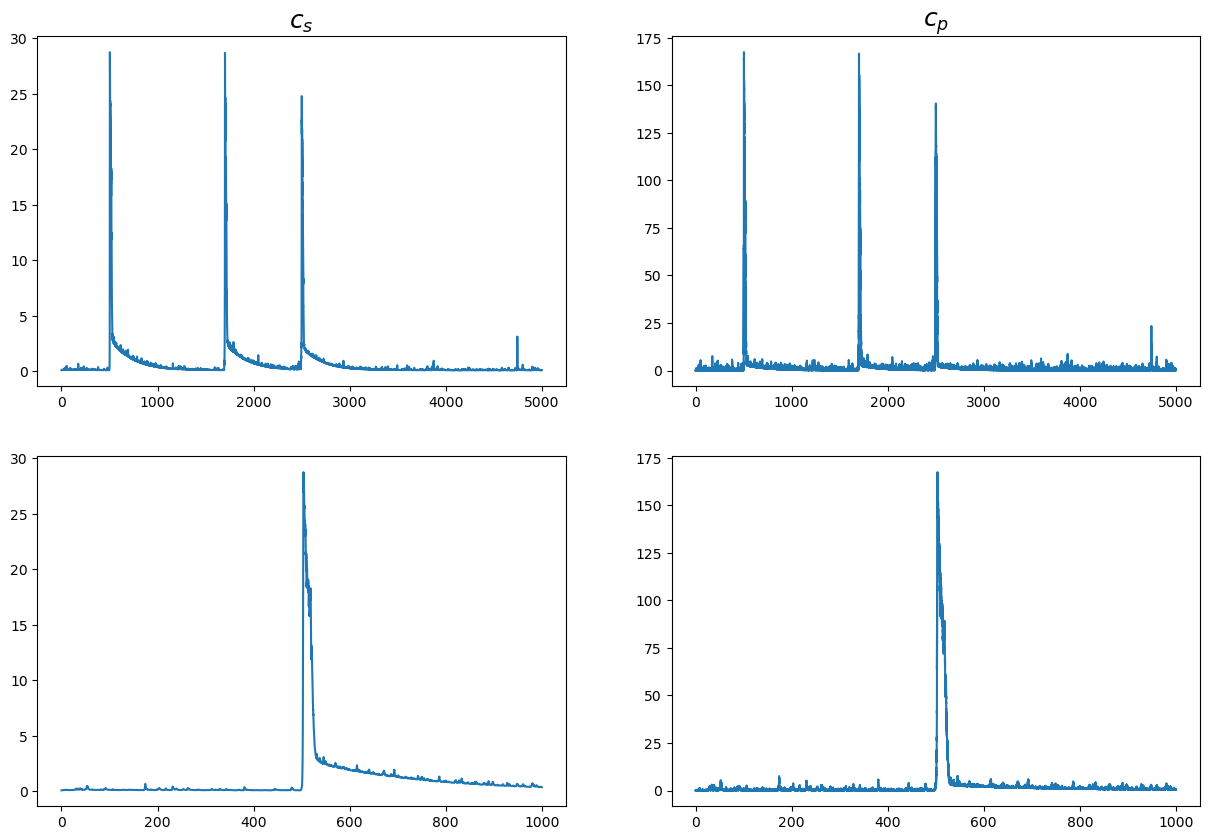

In [192]:
fig, ax = plt.subplots(2,2, figsize=(15,10))
ax[0,0].set_title(r"$c_s$", fontsize=18)
ax[0,0].plot(nb_cru.t, nb_cru.cs)
ax[1,0].plot(nb_cru.t[:1_000_000], nb_cru.cs[:1_000_000])

ax[0,1].set_title(r"$c_p$", fontsize=18)
ax[0,1].plot(nb_cru.t, nb_cru.cp)
ax[1,1].plot(nb_cru.t[:1_000_000], nb_cru.cp[:1_000_000])
plt.show()

In [228]:
def calc_a(cru):
    return 1 / ((cru.cjsr - cru.cs)**2) * (2.17 * cru.RyR[..., 0] + 1.61) * 1e-7

def calc_b(cru):
    t1 = 8.4 * cru.RyR[..., 0] * cru.cjsr
    t2 = -8.47 * cru.RyR[..., 0] * cru.cs
    t3 = 6.25 * cru.cjsr
    t4 = 6.30 * cru.cs
    return 1e-5 * (t1 + t2 + t3 + t4) / (cru.cjsr - cru.cs)**2

def calc_c(cru):
    t1 = -1.69 * cru.RyR[..., 0] * cru.cjsr**2
    t2 = 1.69 * cru.RyR[..., 0] * cru.cs * cru.cjsr
    t3 = -0.754 * cru.cjsr**2
    t4 = 0.259 * cru.cs * cru.cjsr
    t5 = 0.5 * cru.cs ** 2
    return 1e-4 * (t1 + t2 + t3 + t4 + t5 - 25.67) / (cru.cjsr - cru.cs)**2

def calc_d_partial(cru):
    t1 = 8.45 * cru.RyR[..., 0] * cru.cjsr**3
    t2 = -8.47 * cru.RyR[..., 0] * cru.cs * cru.cjsr**2
    t3 = 1.28 * cru.cjsr**3
    t4 = 3.7 * cru.cs * cru.cjsr**2
    t5 = -5 * cru.cs ** 2
    return 1e-5 * (t1 + t2 + t3 + t4 + t5) / (cru.cjsr - cru.cs)**2


In [232]:
np.quantile(calc_d_partial(nb_cru) * nb_cru.cp**2, 0.95)

0.1723055435225182

In [24]:
t_rn, cs_rn = time_renormalisation(nb_cru.cs, nb_cru.t, niter=10)
_, cp_rn = time_renormalisation(nb_cru.cp, nb_cru.t, niter=10)

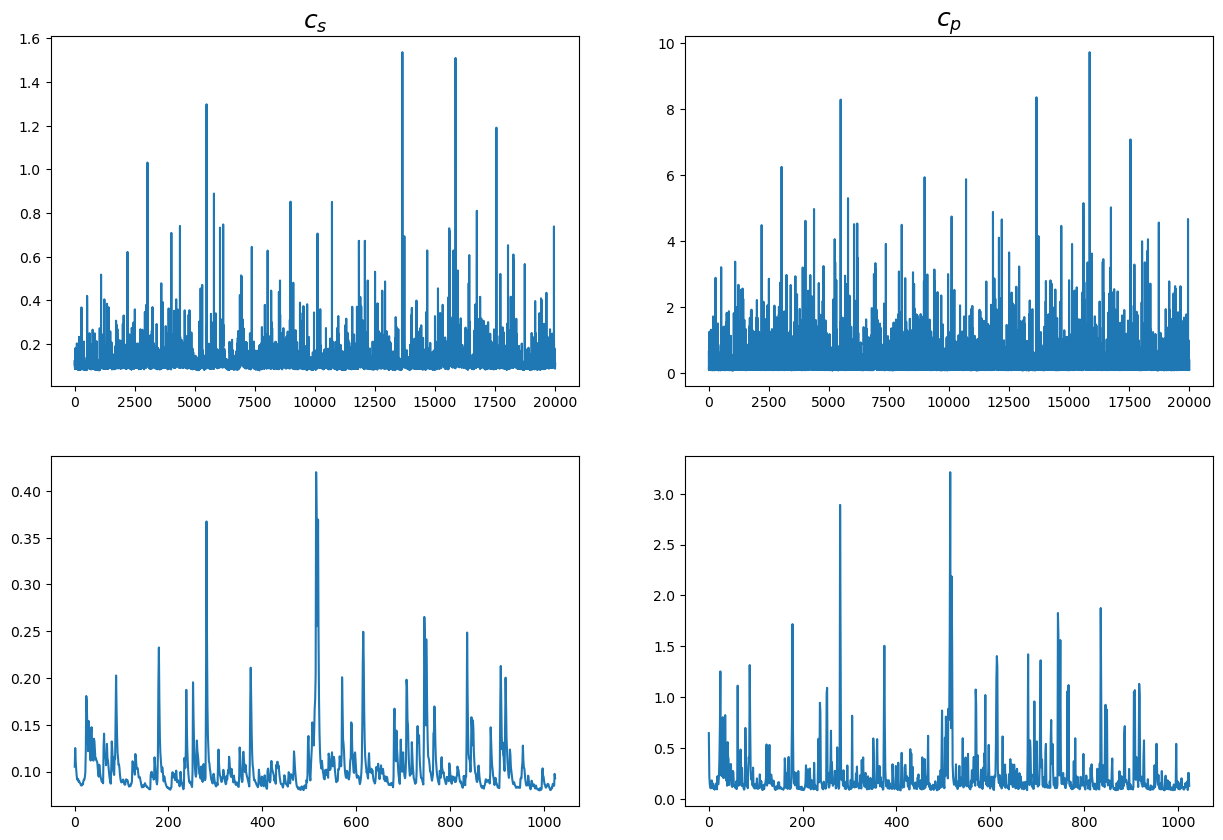

In [25]:
fig, ax = plt.subplots(2,2, figsize=(15,10))
ax[0,0].set_title(r"$c_s$", fontsize=18)
ax[0,0].plot(t_rn, cs_rn)
ax[1,0].plot(t_rn[:1000], cs_rn[:1000])

ax[0,1].set_title(r"$c_p$", fontsize=18)
ax[0,1].plot(t_rn, cp_rn)
ax[1,1].plot(t_rn[:1000], cp_rn[:1000])
plt.show()

In [26]:
mu = (cs_rn[cs_rn< 2.0] - cs_rn.min()).mean()
r = 0.28
sigma = np.sqrt(2*r*(mu*(1/(cs_rn[cs_rn<2.0] - cs_rn.min()+1e-4)).mean()-1))
ts, gbm = mean_reverting_gbm(mu, mu, sigma, r, 1e-3, 10_000_000)

In [27]:
sigma**2 / (2*r)

1.2455486163113516

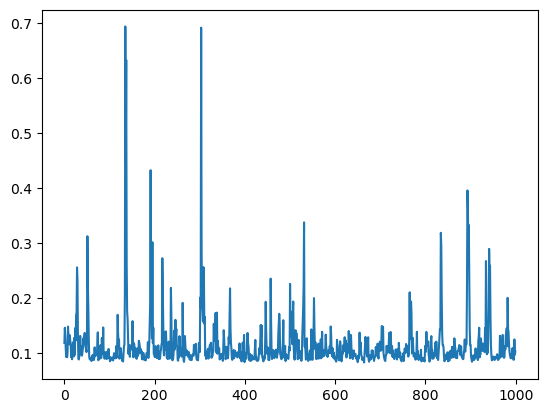

In [28]:
plt.plot(ts[:1_000_000:1000], gbm[:1_000_000:1000] + cs_rn.min())
plt.show()

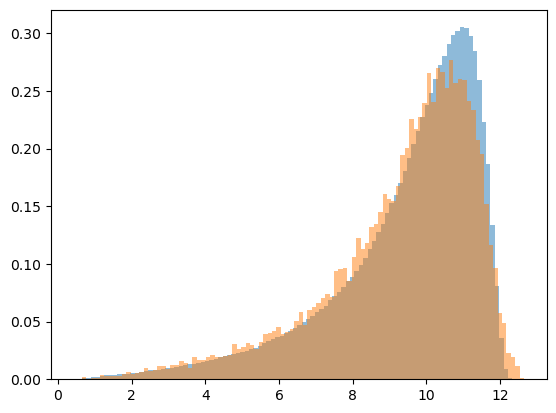

In [29]:
plt.hist(1 / (gbm + cs_rn.min()), density=True, alpha=0.5, bins=100)
plt.hist(1 / cs_rn, density=True, alpha=0.5, bins=100)
plt.show()

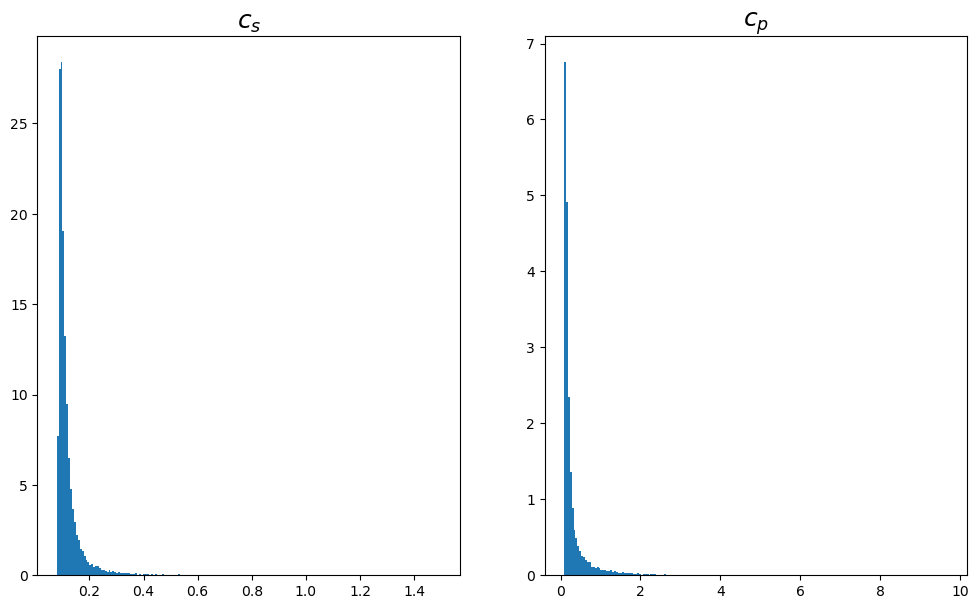

In [66]:
fig, ax = plt.subplots(1,2, figsize=(12,7))
ax[0].set_title(r"$c_s$", fontsize=18)
ax[0].hist(cs_rn[cs_rn < 5.0], bins=200, density=True)
ax[1].set_title(r"$c_p$", fontsize=18)
ax[1].hist(cp_rn[cp_rn < 20], bins=200, density=True)
plt.show()

In [67]:
m_cs = ((cs_rn[cs_rn < 2.0]-cs_rn.min())).mean()
v_cs = ((cs_rn[cs_rn < 2.0]-cs_rn.min())).var()

m_cp = ((cp_rn[cp_rn < 20.0]-cp_rn.min())).mean()
v_cp = ((cp_rn[cp_rn < 20.0]-cp_rn.min())).var()

In [68]:
alpha_cs = 2 + m_cs**2 / v_cs
beta_cs = (alpha_cs - 1) * m_cs

alpha_cp = 2 + m_cp**2 / v_cp
beta_cp = (alpha_cp - 1) * m_cp

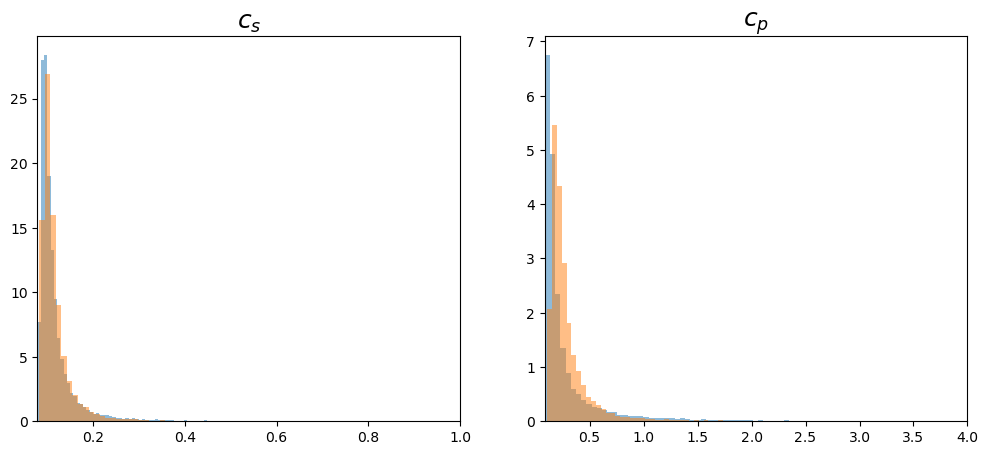

In [69]:
#log_cs_shifted = np.log((np.sort(cs_rn[cs_rn < 2.0])[1:] - cs_rn.min()))
#log_cp_shifted = np.log((np.sort(cp_rn[cp_rn < 20.0])[1:] - cp_rn.min()))

gammas_cs = np.random.gamma(shape=alpha_cs, scale=1/beta_cs, size=cs_rn.shape[0])
gammas_cp = np.random.gamma(shape=alpha_cp, scale=1/beta_cp, size=cp_rn.shape[0])

ig_cs = 1 / gammas_cs + cs_rn.min()
ig_cp = 1 / gammas_cp + cp_rn.min()


fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].set_title(r"$c_s$", fontsize=18)
ax[0].hist((cs_rn[cs_rn < 5.0]), bins=200, density=True, alpha=0.5)
ax[0].hist(ig_cs[ig_cs < 5.0], bins=200, density=True, alpha=0.5)
ax[0].set_xlim(cs_rn.min(),1)

ax[1].set_title(r"$c_p$", fontsize=18)
ax[1].hist(cp_rn[cp_rn < 20.0], bins=200, density=True, alpha=0.5)
ax[1].hist(ig_cp, bins=400, density=True, alpha=0.5)
ax[1].set_xlim(cp_rn.min(),4)
plt.show()

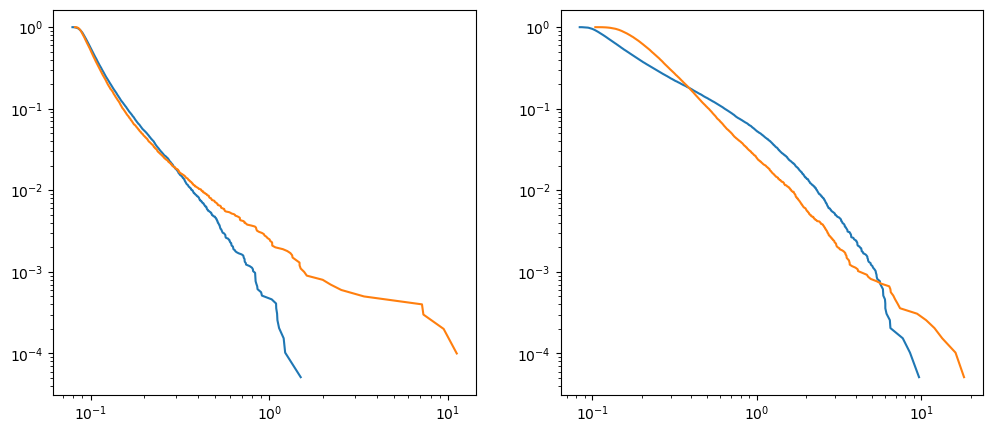

In [70]:
cs_ps, cs_bins = ccdf(cs_rn[cs_rn < 2.0])
cp_ps, cp_bins = ccdf(cp_rn[cp_rn < 20.0])

ig_cs_ps, ig_cs_bins = ccdf(gbm[::1000] + cs_rn.min())
ig_cp_ps, ig_cp_bins = ccdf(ig_cp)

fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].plot(cs_bins, cs_ps)
ax[0].plot(ig_cs_bins, ig_cs_ps)
ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].plot(cp_bins, cp_ps)
ax[1].plot(ig_cp_bins, ig_cp_ps)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
plt.show()

In [143]:
def acf(arr: npt.NDArray, demean: bool = True):
    if demean:
        x = arr - arr.mean()
    else:
        x = arr

    corr = np.correlate(x, x, mode='full')
    corr /= np.dot(x, x)
    return corr[len(corr)//2:]

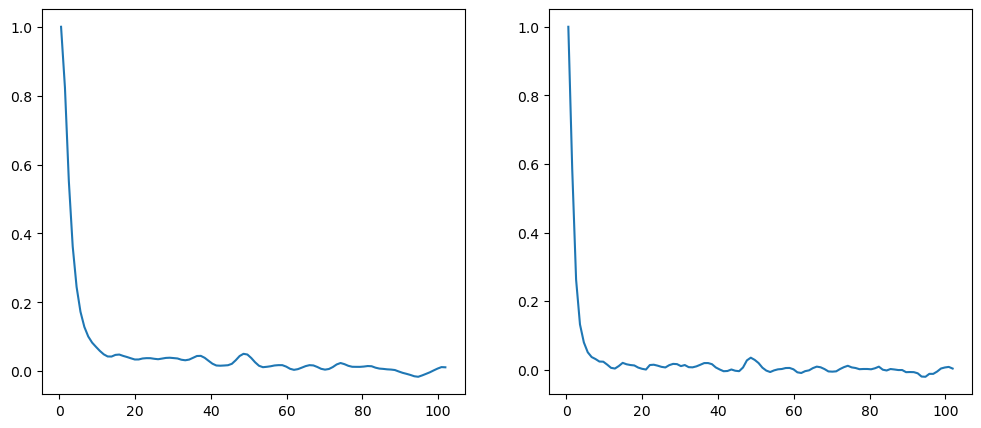

In [144]:
cs_acf = acf(cs_rn)
cp_acf = acf(cp_rn)

fig, ax = plt.subplots(1,2,figsize=(12,5))
ax[0].plot(t_rn[:100], cs_acf[:100])
ax[1].plot(t_rn[:100], cp_acf[:100])
plt.show()

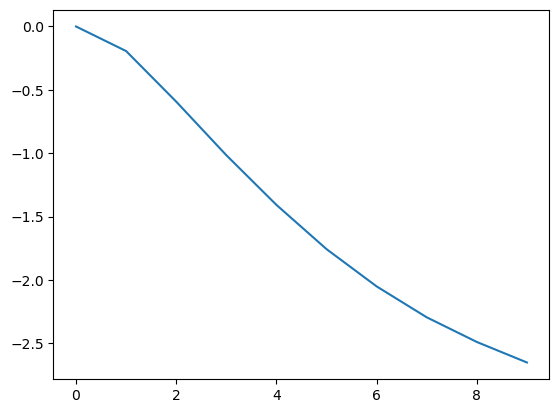

In [145]:
plt.plot(np.log(cs_acf[:10]))
plt.show()

In [146]:
np.log(cs_acf[10] / cs_acf[0]) / (t_rn[10] - t_rn[0])

-0.2767609785623863

In [26]:
# Delete big arrays
try:
    del nb_cru
except:
    pass

In [2]:
b_cru = RestrepoCPU(boundary=True)

In [50]:
V = -40.0
Nai = 78.0

In [87]:
b_cru.forward(1e-3, 50_000_000, V=V, Nai=Nai)

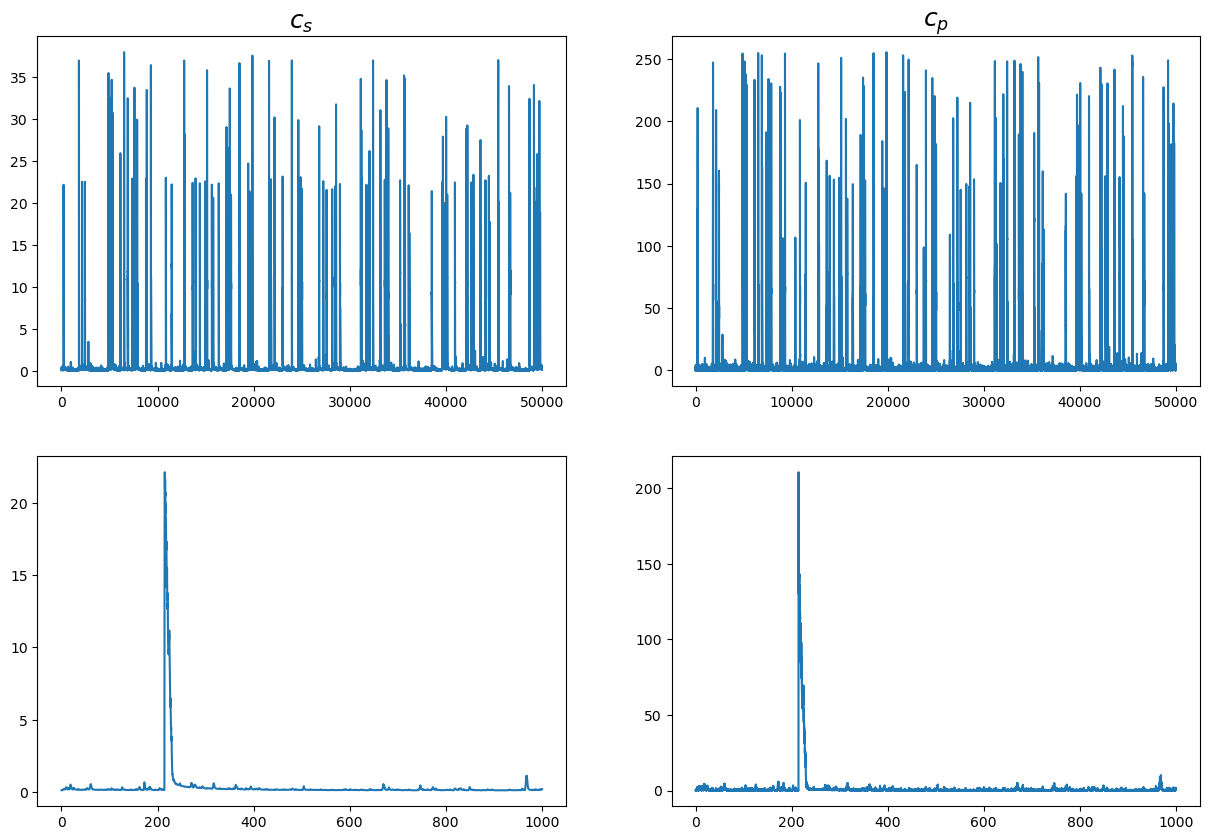

In [88]:
fig, ax = plt.subplots(2,2, figsize=(15,10))
ax[0,0].set_title(r"$c_s$", fontsize=18)
ax[0,0].plot(b_cru.t, b_cru.cs)
ax[1,0].plot(b_cru.t[:1_000_000], b_cru.cs[:1_000_000])

ax[0,1].set_title(r"$c_p$", fontsize=18)
ax[0,1].plot(b_cru.t, b_cru.cp)
ax[1,1].plot(b_cru.t[:1_000_000], b_cru.cp[:1_000_000])
plt.show()

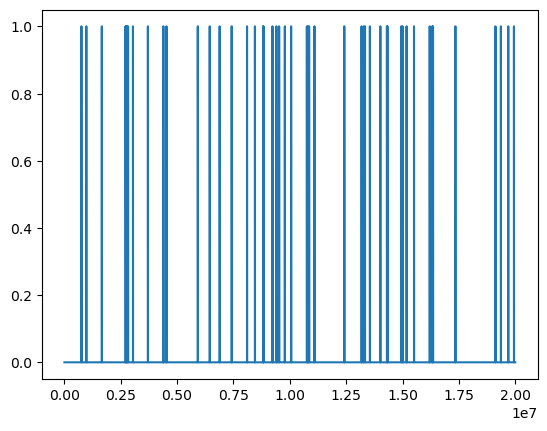

In [59]:
plt.plot((b_cru.LCC == 7).sum(axis=-1))
plt.show()

In [89]:
t_rn, cs_rn = time_renormalisation(b_cru.cs, b_cru.t, niter=10)
_, cp_rn = time_renormalisation(b_cru.cp, b_cru.t, niter=10)

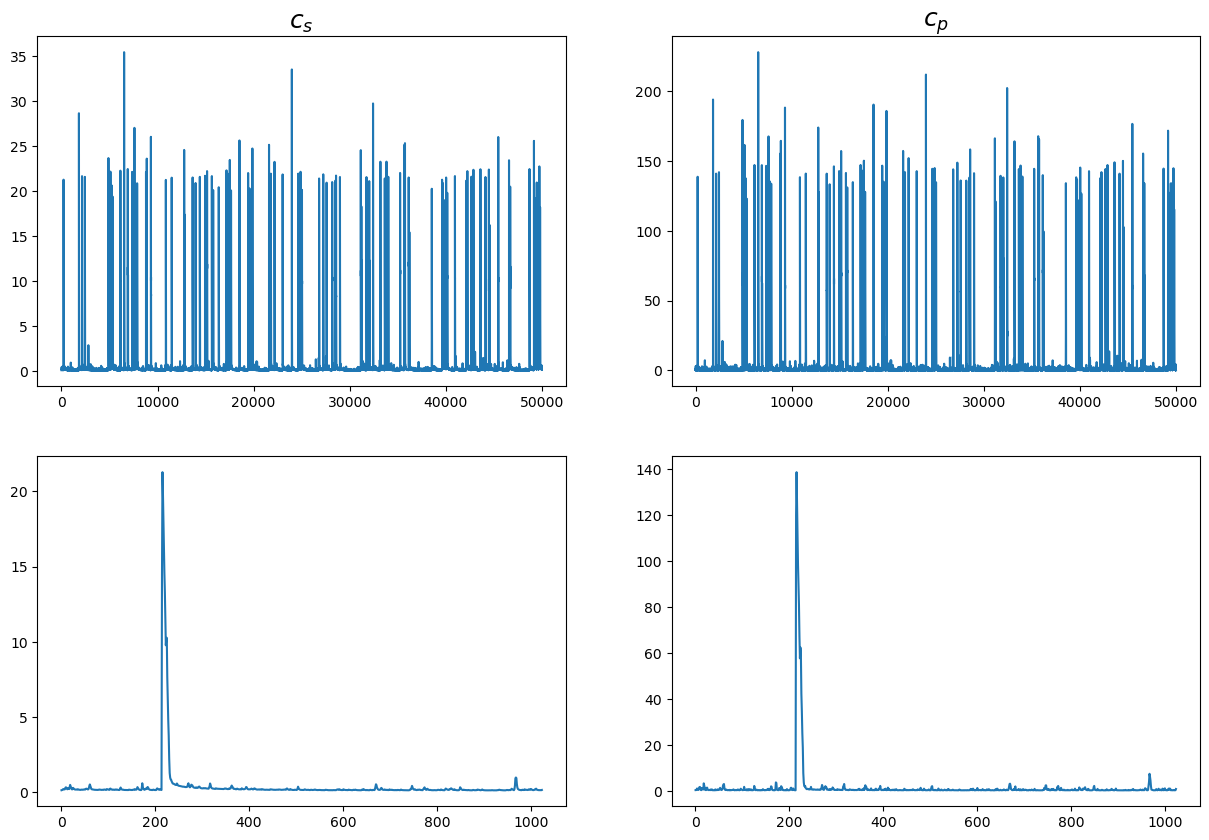

In [90]:
fig, ax = plt.subplots(2,2, figsize=(15,10))
ax[0,0].set_title(r"$c_s$", fontsize=18)
ax[0,0].plot(t_rn, cs_rn)
ax[1,0].plot(t_rn[:1000], cs_rn[:1000])

ax[0,1].set_title(r"$c_p$", fontsize=18)
ax[0,1].plot(t_rn, cp_rn)
ax[1,1].plot(t_rn[:1000], cp_rn[:1000])
plt.show()

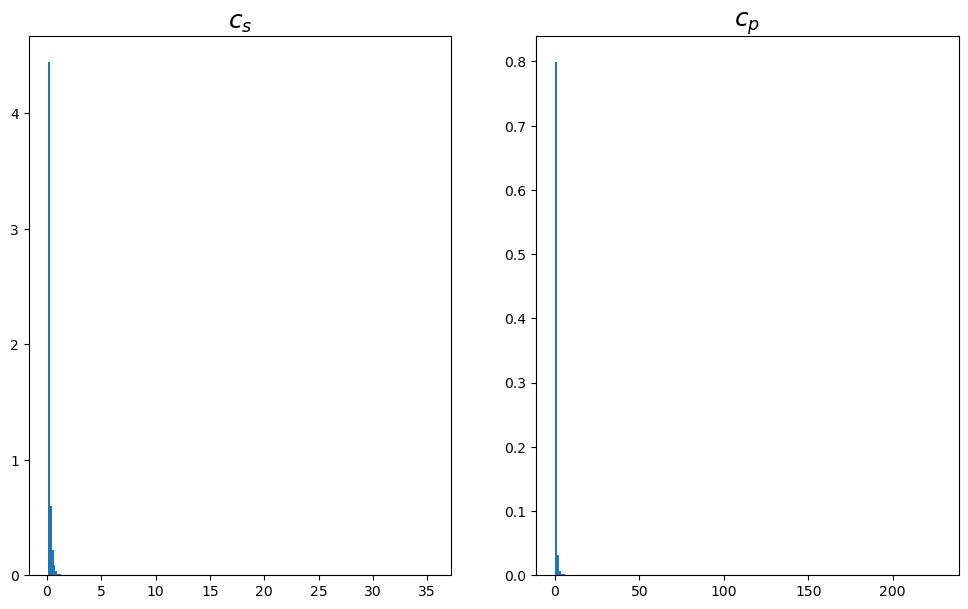

In [91]:
fig, ax = plt.subplots(1,2, figsize=(12,7))
ax[0].set_title(r"$c_s$", fontsize=18)
ax[0].hist(cs_rn, bins=200, density=True)
ax[1].set_title(r"$c_p$", fontsize=18)
ax[1].hist(cp_rn, bins=200, density=True)
plt.show()

In [92]:
p_cp, bins_cp = ccdf(cp_rn)
p_cs, bins_cs = ccdf(cs_rn)

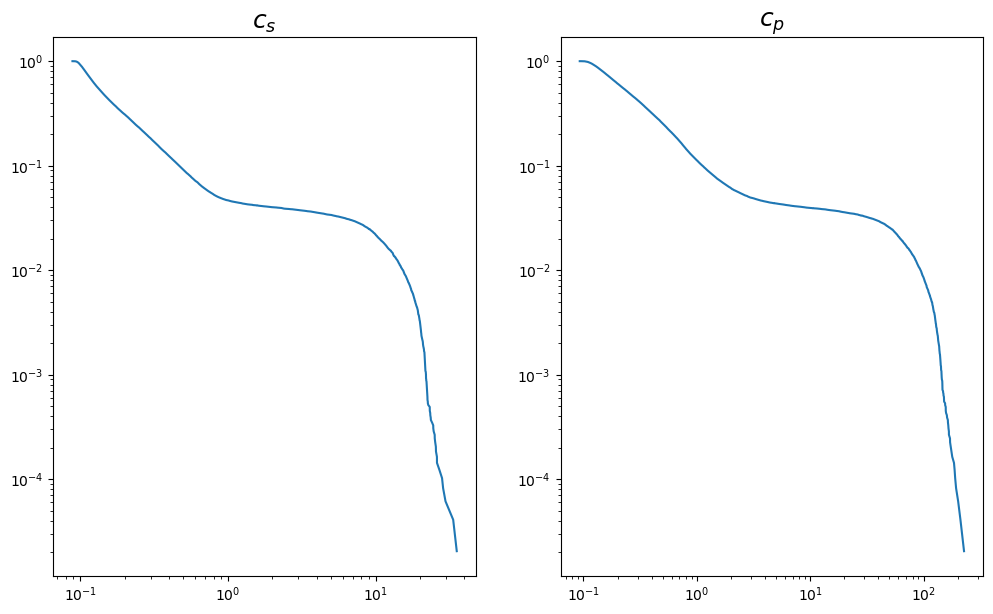

In [93]:
fig, ax = plt.subplots(1,2, figsize=(12,7))
ax[0].set_title(r"$c_s$", fontsize=18)
ax[0].plot(bins_cs, p_cs)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[1].set_title(r"$c_p$", fontsize=18)
ax[1].plot(bins_cp, p_cp)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
plt.show()

In [94]:
jump_candidates = t_rn[np.where(cs_rn > 2.0)[0]]

In [95]:
actual_jump_pos = np.where(jump_candidates[1:] - jump_candidates[:-1] > 2.0)[0]

In [96]:
jumps = np.zeros(len(actual_jump_pos))
for i in range(len(actual_jump_pos)):
    if i == 0:
        left = 0
    else:
        left = actual_jump_pos[i-1]
    right = actual_jump_pos[i]
    jumps[i] = jump_candidates[left:right].mean()

In [97]:
ijt_ps, ijt_bins = ccdf(jumps[1:] - jumps[:-1])

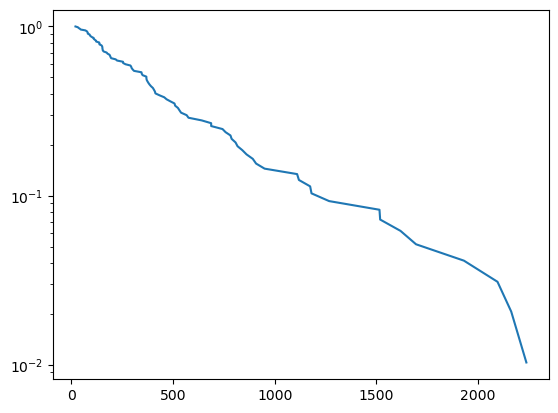

In [98]:
plt.plot(ijt_bins, ijt_ps)
plt.yscale('log')
plt.show()